# PPO

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from env import ForagingEnv

torch.manual_seed(0)
np.random.seed(0)

VARIANTS = ["V1", "V2", "V3"]
N_SEEDS = 5
N_EPISODES = 1000

## Actor-Critic Network

In [ ]:
class ActorCritic(nn.Module):
    """
    Shared-trunk actor-critic network.

    Actor:  s -> pi(a|s)   (Categorical distribution over 4 actions)
    Critic: s -> V(s)      (scalar value estimate)
    """

    def __init__(self, obs_size, n_actions, hidden_size=64):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(obs_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
        )
        self.actor = nn.Linear(hidden_size, n_actions)
        self.critic = nn.Linear(hidden_size, 1)

    def forward(self, x):
        features = self.trunk(x)
        logits = self.actor(features)
        value = self.critic(features).squeeze(-1)
        return logits, value

    def select_action(self, obs):
        """
        Sample action from policy.
        Returns (action, log_prob, value_estimate).
        """
        obs_t = torch.FloatTensor(obs).unsqueeze(0)
        logits, value = self.forward(obs_t)
        dist = torch.distributions.Categorical(logits=logits.squeeze(0))
        action = dist.sample()
        return action.item(), dist.log_prob(action), value.squeeze()

## Generalized Advantage Estimation (GAE)

In [ ]:
def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    """
    Compute GAE advantages and discounted returns.

    Args:
        rewards: list of rewards from one episode
        values:  list of V(s_t) estimates (as tensors)
        dones:   list of done flags
        gamma:   discount factor
        lam:     GAE lambda

    Returns:
        advantages: torch.FloatTensor, shape (T,)
        returns:    torch.FloatTensor, shape (T,)  [used to train critic]
    """
    values = torch.stack(values).detach()
    # Bootstrap with 0 for terminal state
    values_np = values.numpy()
    adv = np.zeros(len(rewards), dtype=np.float32)
    last_gae = 0.0

    for t in reversed(range(len(rewards))):
        next_val = 0.0 if dones[t] else values_np[t+1] \
            if t+1 < len(values_np) else 0.0
        delta = rewards[t] + gamma * next_val - values_np[t]
        last_gae = delta + gamma * lam * (0.0 if dones[t] else last_gae)
        adv[t] = last_gae

    advantages = torch.FloatTensor(adv)
    returns = advantages + values 
    return advantages, returns

## PPO Update

In [ ]:
def ppo_update(ac, opt, obs_buf, act_buf, old_logp_buf,
               adv_buf, ret_buf,
               clip_eps=0.2, epochs=4, batch_size=64,
               vf_coef=0.5, ent_coef=0.01):
    """
    Run K epochs of PPO updates on the collected trajectory buffer.

    Args:
        ac:           ActorCritic network
        opt:          optimizer
        obs_buf:      (T, obs_size) FloatTensor
        act_buf:      (T,) LongTensor
        old_logp_buf: (T,) FloatTensor  [log probs under old policy]
        adv_buf:      (T,) FloatTensor
        ret_buf:      (T,) FloatTensor  [targets for critic]
        clip_eps:     PPO clipping parameter ε
        epochs:       number of update epochs per trajectory
        batch_size:   minibatch size
        vf_coef:      critic loss weight c1
        ent_coef:     entropy bonus weight c2
    """
    T = obs_buf.shape[0]
    adv_buf = (adv_buf - adv_buf.mean()) / (adv_buf.std() + 1e-8)

    for _ in range(epochs):
        idxs = torch.randperm(T)
        for start in range(0, T, batch_size):
            mb = idxs[start:start+batch_size]

            logits, values = ac(obs_buf[mb])
            dist = torch.distributions.Categorical(logits=logits)
            logp = dist.log_prob(act_buf[mb])
            entropy = dist.entropy().mean()

            ratio = torch.exp(logp - old_logp_buf[mb])

            adv_mb = adv_buf[mb]
            surr1 = ratio * adv_mb
            surr2 = torch.clamp(ratio, 1-clip_eps, 1+clip_eps) * adv_mb
            policy_loss = -torch.min(surr1, surr2).mean()

            value_loss = nn.functional.mse_loss(values, ret_buf[mb])

            loss = policy_loss + vf_coef * value_loss - ent_coef * entropy

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ac.parameters(), 0.5)
            opt.step()

## PPO Training Loop

In [ ]:
def train_ppo(variant, seed, n_episodes=N_EPISODES,
              gamma=0.99, lam=0.95, lr=3e-4,
              clip_eps=0.2, epochs=4, print_every=200):
    env = ForagingEnv.make(variant, seed=seed)
    ac = ActorCritic(env.obs_size, env.n_actions)
    opt = optim.Adam(ac.parameters(), lr=lr)

    food_history = []

    for ep in range(1, n_episodes + 1):
        obs = env.reset()
        obs_list, act_list, logp_list = [], [], []
        val_list, rew_list, don_list = [], [], []
        done = False

        while not done:
            action, logp, val = ac.select_action(obs)
            next_obs, reward, done, info = env.step(action)

            obs_list.append(torch.FloatTensor(obs))
            act_list.append(action)
            logp_list.append(logp.detach())
            val_list.append(val.detach())
            rew_list.append(reward)
            don_list.append(done)

            obs = next_obs

        food_history.append(info["food_eaten"])

        advantages, returns = compute_gae(
            rew_list, val_list, don_list, gamma, lam)

        obs_buf = torch.stack(obs_list)
        act_buf = torch.LongTensor(act_list)
        old_logp = torch.stack(logp_list).squeeze(-1)

        ppo_update(ac, opt, obs_buf, act_buf, old_logp,
                   advantages, returns,
                   clip_eps=clip_eps, epochs=epochs)

        if ep % print_every == 0:
            avg = np.mean(food_history[-print_every:])
            print(f"  [{variant}] seed={seed} ep={ep:4d} | "
                  f"avg food (last {print_every}): {avg:.1f}")

    return ac, food_history

## Train Across All Variants and Seeds

In [ ]:
results = {}
policies = {}

for variant in VARIANTS:
    print(f"\n=== {variant} ===")
    seed_results = []
    for seed in range(N_SEEDS):
        ac, food_hist = train_ppo(variant, seed=seed)
        seed_results.append(food_hist)
        if seed == 0:
            policies[variant] = ac
    results[variant] = np.array(seed_results)

print("\nAll PPO training complete.")


=== V1 ===
  [V1] seed=0 ep= 200 | avg food (last 200): 33.6
  [V1] seed=0 ep= 400 | avg food (last 200): 62.5
  [V1] seed=0 ep= 600 | avg food (last 200): 81.9
  [V1] seed=0 ep= 800 | avg food (last 200): 93.7
  [V1] seed=0 ep=1000 | avg food (last 200): 102.7
  [V1] seed=1 ep= 200 | avg food (last 200): 32.3
  [V1] seed=1 ep= 400 | avg food (last 200): 57.8
  [V1] seed=1 ep= 600 | avg food (last 200): 78.1
  [V1] seed=1 ep= 800 | avg food (last 200): 90.3
  [V1] seed=1 ep=1000 | avg food (last 200): 99.2
  [V1] seed=2 ep= 200 | avg food (last 200): 29.4
  [V1] seed=2 ep= 400 | avg food (last 200): 54.7
  [V1] seed=2 ep= 600 | avg food (last 200): 78.9
  [V1] seed=2 ep= 800 | avg food (last 200): 95.0
  [V1] seed=2 ep=1000 | avg food (last 200): 102.3
  [V1] seed=3 ep= 200 | avg food (last 200): 28.5
  [V1] seed=3 ep= 400 | avg food (last 200): 53.8
  [V1] seed=3 ep= 600 | avg food (last 200): 74.5
  [V1] seed=3 ep= 800 | avg food (last 200): 88.0
  [V1] seed=3 ep=1000 | avg food (la

## Plot Learning Curves per Variant

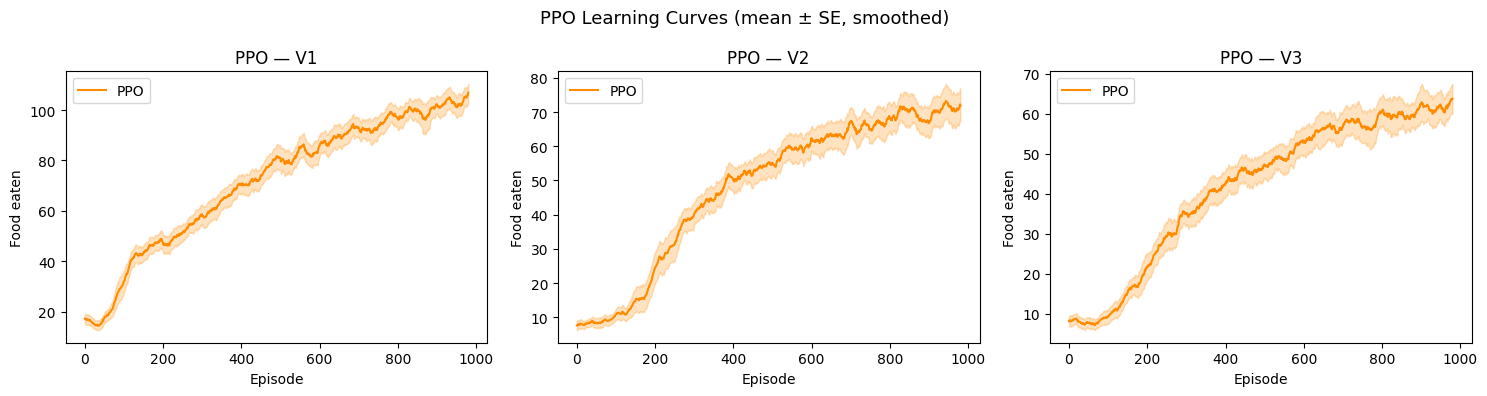

In [7]:
def smooth(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode="valid")


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, variant in zip(axes, VARIANTS):
    data = results[variant]
    mean = data.mean(axis=0)
    se = data.std(axis=0) / np.sqrt(N_SEEDS)
    ep = np.arange(len(smooth(mean)))

    ax.plot(smooth(mean), color="darkorange", label="PPO")
    ax.fill_between(ep,
                    smooth(mean - se),
                    smooth(mean + se),
                    alpha=0.25, color="darkorange")
    ax.set_title(f"PPO — {variant}")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Food eaten")
    ax.legend()

plt.suptitle("PPO Learning Curves (mean ± SE, smoothed)", fontsize=13)
plt.tight_layout()
plt.savefig("ppo_curves.png", dpi=150)
plt.show()

## Sample Efficiency

In [8]:
def episodes_to_threshold(food_hist, threshold_frac=0.8, window=20):
    smoothed = smooth(food_hist, w=window)
    final_perf = smoothed[-1]
    threshold = threshold_frac * final_perf
    hits = np.where(smoothed >= threshold)[0]
    return hits[0] if len(hits) > 0 else len(food_hist)


print("Sample efficiency (episodes to 80% of final performance):")
print(f"{'Variant':<8} {'Mean':>8} {'Std':>8}")
for variant in VARIANTS:
    efficiencies = [
        episodes_to_threshold(results[variant][s])
        for s in range(N_SEEDS)
    ]
    print(f"{variant:<8} {np.mean(efficiencies):>8.0f} "
          f"{np.std(efficiencies):>8.0f}")

Sample efficiency (episodes to 80% of final performance):
Variant      Mean      Std
V1            547       52
V2            502       42
V3            538       63


## Save Results and Policies

In [9]:
np.save("ppo_results.npy", results, allow_pickle=True)

for variant in VARIANTS:
    torch.save(policies[variant].state_dict(),
               f"ppo_policy_{variant}.pt")

print("Saved ppo_results.npy")
print("Saved ppo_policy_V1/V2/V3.pt")

Saved ppo_results.npy
Saved ppo_policy_V1/V2/V3.pt


## Behavioural Check

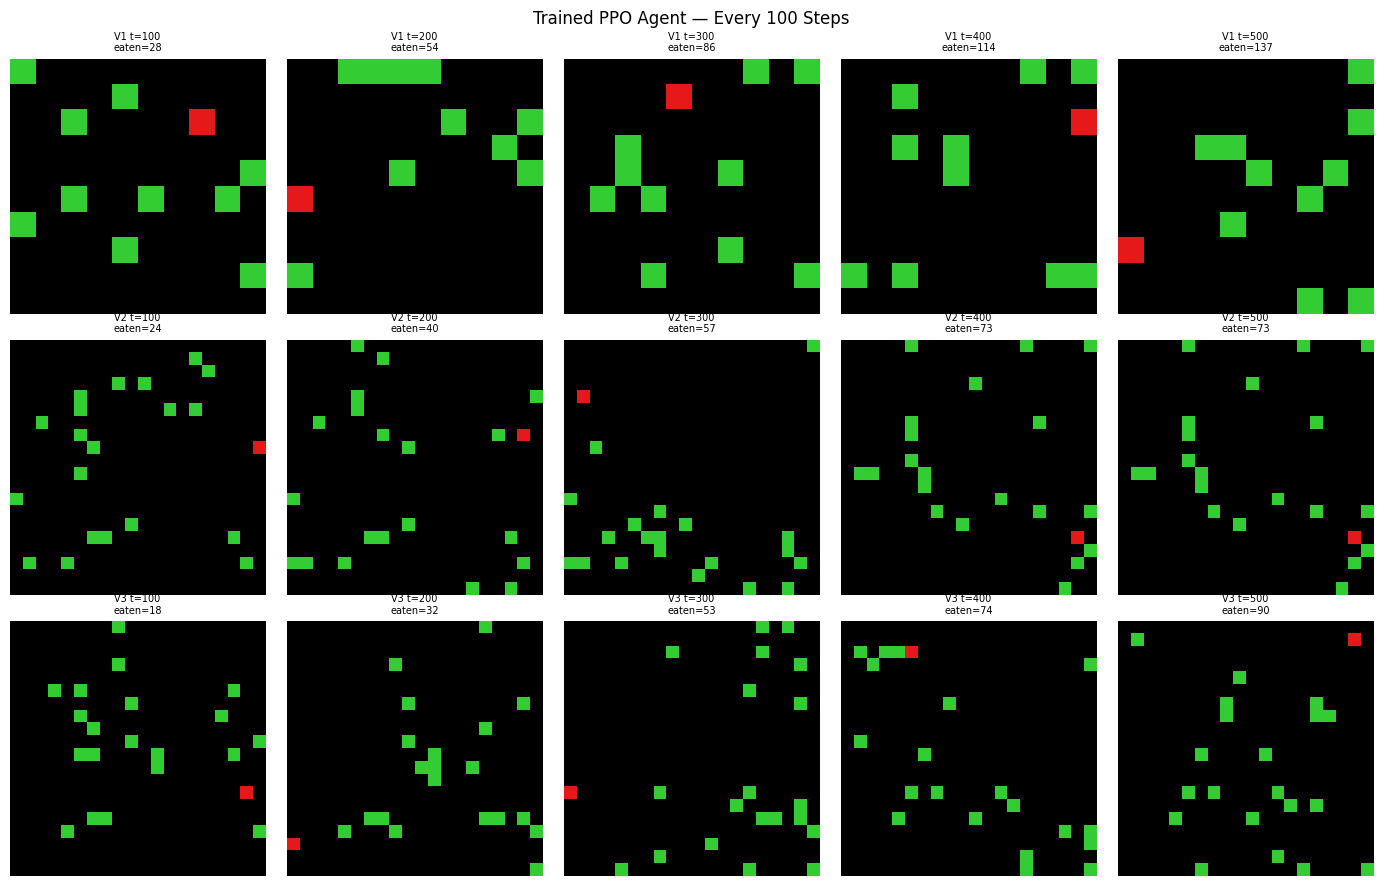

In [10]:
fig, axes = plt.subplots(3, 5, figsize=(14, 9))

for row, variant in enumerate(VARIANTS):
    env = ForagingEnv.make(variant, seed=99)
    obs = env.reset()
    done, col = False, 0
    ac = policies[variant]

    with torch.no_grad():
        while not done and col < 5:
            obs_t = torch.FloatTensor(obs).unsqueeze(0)
            logits, _ = ac(obs_t)
            action = logits.argmax().item()
            obs, _, done, info = env.step(action)

            if env.steps % 100 == 0:
                img = np.zeros((env.grid_size, env.grid_size, 3))
                for (r, c) in env.food_positions:
                    img[r, c] = [0.2, 0.8, 0.2]
                img[env.agent_pos[0], env.agent_pos[1]] = [0.9, 0.1, 0.1]
                axes[row][col].imshow(img, origin="upper")
                axes[row][col].set_title(
                    f"{variant} t={env.steps}\neaten={info['food_eaten']}",
                    fontsize=7)
                axes[row][col].axis("off")
                col += 1

plt.suptitle("Trained PPO Agent — Every 100 Steps", fontsize=12)
plt.tight_layout()
plt.savefig("ppo_behaviour.png", dpi=150)
plt.show()